## 01-rnn: Experiment 노트북

### 목표
- RNN, LSTM backbone에서 각각 long-term dependency를 어떻게 처리하는지 성능 비교
- 직접 구현한 Character-level Language Model을 학습 및 평가
- 학습 loss 및 gradient 시각화
- 학습 checkpoint 저장 및 복원 기능 구현

### 1. Import 및 설정

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import math
import random
from typing import Tuple, Dict

import torch
import torch.nn as nn
from torch import Tensor
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from model import CharacterLM
from rnn import RNN
from lstm import LSTM

from utils.tokenizer import get_vocab, char_tokenizer

In [3]:
def set_random(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.random.manual_seed(seed)

set_random()

### 2. Dataset 생성

#### Character-level LM Dataset
- 각 시점의 다음 timestep 문자를 예측할 수 있는지를 검증

In [4]:
def encode_text(
        text: str,
        char_to_id: Dict[str, int]
) -> torch.LongTensor:
    """
    문자열 1개가 들어오면, token_id로 변환하여 반환
    """
    token_ids = [char_to_id[c] for c in text]
    token_ids = torch.LongTensor(token_ids)
    return token_ids

text = "hello world"
vocab = get_vocab([text], char_tokenizer)
char_to_id = {c: i for i, c in enumerate(vocab)}
encoded_text = encode_text(text, char_to_id)

assert len(encoded_text) == len(text)
assert encoded_text.dtype == torch.long

In [5]:
def create_lm_dataset(
        token_ids: torch.LongTensor, seq_len: int
    ) -> Tuple[Tensor, Tensor]:
    """
    token_id로 변환된 문자열이 들어오면, seq_len 만큼 데이터셋을 구성
    """
    assert len(token_ids) > seq_len
    windows = token_ids.unfold(0, seq_len+1, 1)

    inputs = windows[:, :-1]
    targets = windows[:, 1:]

    return inputs, targets

inputs, targets = create_lm_dataset(encoded_text, 3)

assert inputs.shape == targets.shape
assert torch.allclose(inputs[:, 1:], targets[:, :-1])

안드레 카파시의 "tiny shakespeare"를 데이터셋으로 활용함

[링크](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt)

In [6]:
with open('data/tiny-shakespeare.txt') as f:
    text = f.read()

text = text[:50_000] # 50,000자만 사용
vocab = get_vocab(corpus=[text], tokenize_fn=char_tokenizer)
char_to_id = {c: i for i, c in enumerate(vocab)}
id_to_char = {i: c for c, i in char_to_id.items()}
token_ids = encode_text(text, char_to_id)

In [7]:
sequence_len = 32
train_len = int(len(text)*0.9)
train_token_ids = token_ids[:train_len]
valid_token_ids = token_ids[train_len:]

assert train_token_ids.dtype == torch.long
assert valid_token_ids.dtype == torch.long
assert len(text) == len(train_token_ids) + len(valid_token_ids)
assert len(train_token_ids) > 32 and len(valid_token_ids) > 32

In [8]:
train_input_ids, train_target_ids = create_lm_dataset(token_ids=train_token_ids, seq_len=sequence_len)
valid_input_ids, valid_target_ids = create_lm_dataset(token_ids=valid_token_ids, seq_len=sequence_len)

assert len(train_input_ids) == len(train_token_ids) - sequence_len
assert len(valid_input_ids) == len(valid_token_ids) - sequence_len

#### DataLoader 구성

In [9]:
train_dataset = TensorDataset(train_input_ids, train_target_ids)
valid_dataset = TensorDataset(valid_input_ids, valid_target_ids)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

### 3. Train

#### 3-1. CharacterLM Train step

In [10]:
def train_step(model, inputs, targets, loss_fn, optimizer, device):
    model.train()
    inputs, targets = inputs.to(device), targets.to(device)
    optimizer.zero_grad()
    logits, _ = model(inputs)
    loss = loss_fn(logits.flatten(0, 1), targets.flatten())
    loss.backward()
    optimizer.step()
    return loss.item()

#### 3-2. Evaluation 함수 제작

In [11]:
def evaluate(model, dataloader, loss_fn, device):
    model.eval()

    total_loss, total_tokens = 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            loss = loss_fn(logits.flatten(0, 1), targets.flatten())

            num_tokens = len(targets)
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)

    return avg_loss, ppl

#### 3-3. 전체 Train Loop 함수 제작

In [12]:
def fit(model, train_loader, valid_loader, loss_fn, optimizer, num_epochs, device):
    train_loss, valid_loss, valid_ppl = [], [], []
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = 0
        total_count = 0
        for inputs, targets in train_loader:
            running_loss = train_step(
                model, inputs, targets, loss_fn, optimizer, device
            )
            epoch_loss += running_loss * len(targets)
            total_count += len(targets)
        running_loss = epoch_loss / total_count
        train_loss.append(running_loss)

        eval_loss, eval_ppl = evaluate(model, valid_loader, loss_fn, device)
        valid_loss.append(eval_loss)
        valid_ppl.append(eval_ppl)

        print(f"Epoch {epoch + 1}: Train Loss={running_loss:.4f}, Valid Loss={eval_loss:.4f}, Valid PPL={eval_ppl:.2f}")

    return train_loss, valid_loss, valid_ppl

### 4. RNN vs LSTM 학습 비교
동일한 데이터, seed, embedding/hidden size, optimizer 설정으로 backbone만 바꿔 비교

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vocab_size = len(vocab)
emb_size = 32
hidden_size = 64
num_epochs = 20

models = {}
for name, backbone_cls in {'RNN': RNN, 'LSTM': LSTM}.items():
    set_random(42)
    models[name] = CharacterLM(
        backbone=backbone_cls(emb_size, hidden_size),
        vocab_size=vocab_size,
        emb_size=emb_size,
        hidden_size=hidden_size,
    ).to(device)

loss_fn = nn.CrossEntropyLoss()
histories = {}
for name, model in models.items():
    print(f'\n{name} training on {device}')
    set_random(42)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    histories[name] = fit(
        model, train_loader, valid_loader, loss_fn, optimizer, num_epochs, device
    )


RNN training on cuda


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Train Loss=3.1555, Valid Loss=2.8647, Valid PPL=17.54
Epoch 2: Train Loss=2.8574, Valid Loss=2.7903, Valid PPL=16.29
Epoch 3: Train Loss=2.7923, Valid Loss=2.7395, Valid PPL=15.48
Epoch 4: Train Loss=2.7554, Valid Loss=2.7114, Valid PPL=15.05
Epoch 5: Train Loss=2.7346, Valid Loss=2.7061, Valid PPL=14.97
Epoch 6: Train Loss=2.7276, Valid Loss=2.7014, Valid PPL=14.90
Epoch 7: Train Loss=2.7213, Valid Loss=2.6962, Valid PPL=14.82
Epoch 8: Train Loss=2.7171, Valid Loss=2.6910, Valid PPL=14.75
Epoch 9: Train Loss=2.7120, Valid Loss=2.6859, Valid PPL=14.67
Epoch 10: Train Loss=2.7080, Valid Loss=2.6826, Valid PPL=14.62
Epoch 11: Train Loss=2.7036, Valid Loss=2.6772, Valid PPL=14.54
Epoch 12: Train Loss=2.6997, Valid Loss=2.6738, Valid PPL=14.50
Epoch 13: Train Loss=2.6968, Valid Loss=2.6704, Valid PPL=14.45
Epoch 14: Train Loss=2.6908, Valid Loss=2.6708, Valid PPL=14.45
Epoch 15: Train Loss=2.6881, Valid Loss=2.6670, Valid PPL=14.40
Epoch 16: Train Loss=2.6873, Valid Loss=2.6680, V

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Train Loss=3.0656, Valid Loss=2.6466, Valid PPL=14.11
Epoch 2: Train Loss=2.5572, Valid Loss=2.4751, Valid PPL=11.88
Epoch 3: Train Loss=2.3912, Valid Loss=2.3594, Valid PPL=10.58
Epoch 4: Train Loss=2.2594, Valid Loss=2.2638, Valid PPL=9.62
Epoch 5: Train Loss=2.1464, Valid Loss=2.1800, Valid PPL=8.85
Epoch 6: Train Loss=2.0503, Valid Loss=2.1099, Valid PPL=8.25
Epoch 7: Train Loss=1.9676, Valid Loss=2.0481, Valid PPL=7.75
Epoch 8: Train Loss=1.8949, Valid Loss=1.9970, Valid PPL=7.37
Epoch 9: Train Loss=1.8307, Valid Loss=1.9579, Valid PPL=7.08
Epoch 10: Train Loss=1.7739, Valid Loss=1.9314, Valid PPL=6.90
Epoch 11: Train Loss=1.7253, Valid Loss=1.9128, Valid PPL=6.77
Epoch 12: Train Loss=1.6838, Valid Loss=1.9045, Valid PPL=6.72
Epoch 13: Train Loss=1.6488, Valid Loss=1.8981, Valid PPL=6.67
Epoch 14: Train Loss=1.6197, Valid Loss=1.9040, Valid PPL=6.71
Epoch 15: Train Loss=1.5944, Valid Loss=1.9033, Valid PPL=6.71
Epoch 16: Train Loss=1.5727, Valid Loss=1.9109, Valid PPL=6.7

**비슷한 수의 파라미터를 갖는 LSTM과 RNN은?**

- Codex피셜 위 설정의 RNN과 거의 비슷한 Param 수를 갖는 LSTM의 hidden size는 31~32
- 2의 배수에 맞춰 `hidden_size=32`로 실험

In [14]:
model = CharacterLM(
    backbone=LSTM(emb_size, 32),
    vocab_size=vocab_size,
    emb_size=emb_size,
    hidden_size=32,
).to(device)

print(f'\nLSTM Train with smiliar param size with RNN')
set_random(42)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
histories['LSTM2'] = fit(
    model, train_loader, valid_loader, loss_fn, optimizer, num_epochs, device
)


LSTM Train with smiliar param size with RNN


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1: Train Loss=2.8331, Valid Loss=2.3246, Valid PPL=10.22
Epoch 2: Train Loss=2.1853, Valid Loss=2.1341, Valid PPL=8.45
Epoch 3: Train Loss=2.0421, Valid Loss=2.0584, Valid PPL=7.83
Epoch 4: Train Loss=1.9693, Valid Loss=2.0142, Valid PPL=7.49
Epoch 5: Train Loss=1.9214, Valid Loss=1.9872, Valid PPL=7.30
Epoch 6: Train Loss=1.8865, Valid Loss=1.9674, Valid PPL=7.15
Epoch 7: Train Loss=1.8601, Valid Loss=1.9542, Valid PPL=7.06
Epoch 8: Train Loss=1.8392, Valid Loss=1.9442, Valid PPL=6.99
Epoch 9: Train Loss=1.8218, Valid Loss=1.9351, Valid PPL=6.92
Epoch 10: Train Loss=1.8073, Valid Loss=1.9282, Valid PPL=6.88
Epoch 11: Train Loss=1.7950, Valid Loss=1.9224, Valid PPL=6.84
Epoch 12: Train Loss=1.7845, Valid Loss=1.9221, Valid PPL=6.84
Epoch 13: Train Loss=1.7752, Valid Loss=1.9190, Valid PPL=6.81
Epoch 14: Train Loss=1.7669, Valid Loss=1.9165, Valid PPL=6.80
Epoch 15: Train Loss=1.7595, Valid Loss=1.9112, Valid PPL=6.76
Epoch 16: Train Loss=1.7529, Valid Loss=1.9094, Valid PPL=6.75


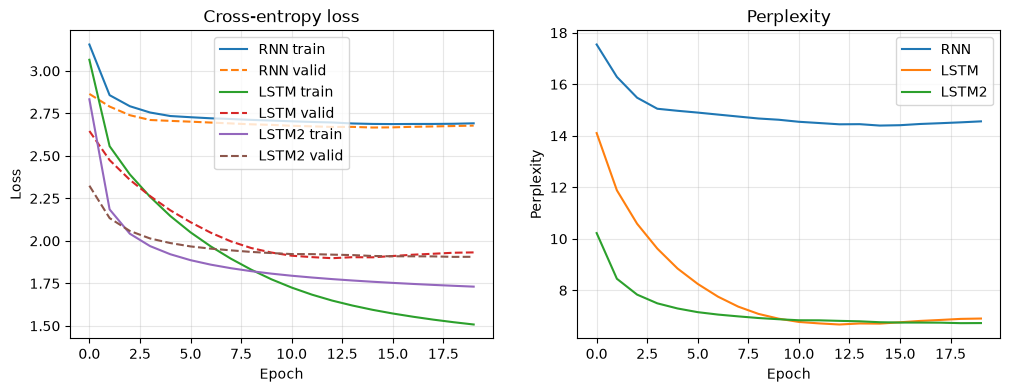

RNN: valid loss=2.6783, accuracy=14.56
LSTM: valid loss=1.9322, accuracy=6.90
LSTM2: valid loss=1.9064, accuracy=6.73


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, (train_loss, valid_loss, valid_ppl) in histories.items():
    axes[0].plot(train_loss, label=f'{name} train')
    axes[0].plot(valid_loss, '--', label=f'{name} valid')
    axes[1].plot(valid_ppl, label=name)

axes[0].set(title='Cross-entropy loss', xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Perplexity', xlabel='Epoch', ylabel='Perplexity')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
plt.show()

for name, (_, valid_loss, valid_ppl) in histories.items():
    print(f'{name}: valid loss={valid_loss[-1]:.4f}, accuracy={valid_ppl[-1]:.2f}')

### 6. RNN vs LSTM 생성 비교

In [16]:
def generate(
        model,
        input_text: str,
        char_to_id: Dict,
        id_to_char: Dict,
        max_new_chars=100,
        temperature=1.0
):
    device = next(model.parameters()).device
    input_token_ids = torch.tensor(
        [char_to_id[c] for c in input_text],
        dtype=torch.long,
        device=device
    )
    generated_text = list(input_text)

    model.eval()
    with torch.no_grad():
        logits, hidden_state = model(input_token_ids)

        for _ in range(max_new_chars):
            next_logits = logits[-1] / temperature

            probabilities = torch.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probabilities, num_samples=1)

            generated_text.append(id_to_char[next_id.item()])
            logits, hidden_state = model(next_id, hidden_state)
    return "".join(generated_text)

In [22]:
prompt = "ROMEO:"

for name, model in models.items():
    set_random(42)

    generated_text = generate(
        model=model,
        input_text=prompt,
        char_to_id=char_to_id,
        id_to_char=id_to_char,
        max_new_chars=300,
        temperature=0.5
    )

    print(f"\n{'=' * 20} {name} {'=' * 20}")
    print(generated_text)


==================== RNN ====================
ROMEO: art te lnd her be sou the su angerata ide tistare me thad e eore re s orthit h the stosr youes hor ithe outh ther ld th s the Iomand thenone,


COMI s hand Iond thas marthe be but hIoad honge I Ioud the te in ha l mome pr
Meats wosp
Tie mas nde th hing tr mou tte r th ou ton s yourithe  th thit at 

==================== LSTM ====================
ROMEO:
You to lady who
thould the conters to the sent the first heart bell.

VOLUMNIA:
I with the perder tius to be confor it their sence vide not that he with you make a shingel
surand to our of hear their seen to that them, I windesser have friendss,
I deed to me fiter.

MARCIUS:
O, the perse that they 
